<a href="https://colab.research.google.com/github/efrathshihab/Betel-Leaf-Disease-Prediction/blob/main/MobileNetV2_Updated.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!nvidia-smi

Thu Aug 27 04:14:39 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
from pathlib import Path

DATASET_DIR = Path("/content/drive/MyDrive/Betel_Leaf_DataSet_916")

print("Dataset path:", DATASET_DIR)
print("Folder exists:", DATASET_DIR.exists())

Dataset path: /content/drive/MyDrive/Betel_Leaf_DataSet_916
Folder exists: True


In [5]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_fscore_support,
    roc_auc_score,
    roc_curve,
    auc,
    r2_score,
    mean_squared_error
)

In [6]:
print("TensorFlow version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [7]:
SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)

In [8]:
from pathlib import Path

DATASET_DIR = Path("/content/drive/MyDrive/Betel_Leaf_DataSet_916")

print("Dataset path:", DATASET_DIR)
print("Folder exists:", DATASET_DIR.exists())

Dataset path: /content/drive/MyDrive/Betel_Leaf_DataSet_916
Folder exists: True


In [10]:
from pathlib import Path

DATASET_DIR = Path("/content/drive/MyDrive/Betel_Leaf_DataSet_916")

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

classes = sorted([
    d.name for d in DATASET_DIR.iterdir()
    if d.is_dir()
])

print("Classes:", classes)

total_images = 0

for class_name in classes:
    class_dir = DATASET_DIR / class_name

    count = sum(
        1 for file in class_dir.iterdir()
        if file.is_file()
        and file.suffix.lower() in IMAGE_EXTENSIONS
    )

    total_images += count
    print(f"{class_name}: {count}")

print("\nTotal Images:", total_images)

Classes: ['Anthracnose', 'Healthy', 'Leaf_Curl', 'Leaf_Rot', 'Leaf_Spot']
Anthracnose: 916
Healthy: 916
Leaf_Curl: 916
Leaf_Rot: 916
Leaf_Spot: 916

Total Images: 4580


In [11]:
IMG_SIZE = (224, 224)

BATCH_SIZE = 32

NUM_CLASSES = 5

In [13]:
from pathlib import Path
import shutil
import random

SEED = 42
random.seed(SEED)

SOURCE_DIR = Path("/content/drive/MyDrive/Betel_Leaf_DataSet_916")
SPLIT_DIR = Path("/content/drive/MyDrive/Betel_Leaf_DataSet_Split")

TRAIN_DIR = SPLIT_DIR / "train"
VAL_DIR = SPLIT_DIR / "validation"
TEST_DIR = SPLIT_DIR / "test"

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

classes = sorted([
    d.name for d in SOURCE_DIR.iterdir()
    if d.is_dir()
])

print("Classes:", classes)

Classes: ['Anthracnose', 'Healthy', 'Leaf_Curl', 'Leaf_Rot', 'Leaf_Spot']


In [15]:
for class_name in classes:

    source_class_dir = SOURCE_DIR / class_name

    images = [
        f for f in source_class_dir.iterdir()
        if f.is_file() and f.suffix.lower() in IMAGE_EXTENSIONS
    ]

    random.shuffle(images)

    total = len(images)

    train_count = 642
    val_count = 137

    train_images = images[:train_count]
    val_images = images[train_count:train_count + val_count]
    test_images = images[train_count + val_count:]

    train_class_dir = TRAIN_DIR / class_name
    val_class_dir = VAL_DIR / class_name
    test_class_dir = TEST_DIR / class_name

    train_class_dir.mkdir(parents=True, exist_ok=True)
    val_class_dir.mkdir(parents=True, exist_ok=True)
    test_class_dir.mkdir(parents=True, exist_ok=True)

    for img in train_images:
        shutil.copy2(img, train_class_dir / img.name)

    for img in val_images:
        shutil.copy2(img, val_class_dir / img.name)

    for img in test_images:
        shutil.copy2(img, test_class_dir / img.name)

    print(
        f"{class_name}: "
        f"Train={len(train_images)}, "
        f"Validation={len(val_images)}, "
        f"Test={len(test_images)}"
    )

Anthracnose: Train=642, Validation=137, Test=137
Healthy: Train=642, Validation=137, Test=137
Leaf_Curl: Train=642, Validation=137, Test=137
Leaf_Rot: Train=642, Validation=137, Test=137
Leaf_Spot: Train=642, Validation=137, Test=137


In [16]:
for split_name, split_dir in [
    ("Train", TRAIN_DIR),
    ("Validation", VAL_DIR),
    ("Test", TEST_DIR)
]:

    print(f"\n{split_name}")

    total = 0

    for class_name in classes:

        class_dir = split_dir / class_name

        count = len([
            f for f in class_dir.iterdir()
            if f.is_file() and f.suffix.lower() in IMAGE_EXTENSIONS
        ])

        total += count
        print(f"{class_name}: {count}")

    print("Total:", total)


Train
Anthracnose: 842
Healthy: 830
Leaf_Curl: 824
Leaf_Rot: 828
Leaf_Spot: 715
Total: 4039

Validation
Anthracnose: 258
Healthy: 245
Leaf_Curl: 252
Leaf_Rot: 248
Leaf_Spot: 137
Total: 1140

Test
Anthracnose: 259
Healthy: 251
Leaf_Curl: 253
Leaf_Rot: 249
Leaf_Spot: 137
Total: 1149


In [18]:
import shutil
from pathlib import Path

SPLIT_DIR = Path("/content/drive/MyDrive/Betel_Leaf_DataSet_Split")

if SPLIT_DIR.exists():
    shutil.rmtree(SPLIT_DIR)
    print("Old split folder deleted successfully.")

Old split folder deleted successfully.


In [19]:
from google.colab import drive
from pathlib import Path

drive.mount('/content/drive')

SOURCE_DIR = Path("/content/drive/MyDrive/Betel_Leaf_DataSet_916")
SPLIT_DIR = Path("/content/drive/MyDrive/Betel_Leaf_DataSet_Split")

print("Original Dataset Exists:", SOURCE_DIR.exists())
print("Split Folder Exists:", SPLIT_DIR.exists())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Original Dataset Exists: True
Split Folder Exists: False


In [20]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

classes = sorted([
    d.name for d in SOURCE_DIR.iterdir()
    if d.is_dir()
])

total_images = 0

for class_name in classes:
    class_dir = SOURCE_DIR / class_name

    count = sum(
        1 for f in class_dir.iterdir()
        if f.is_file() and f.suffix.lower() in IMAGE_EXTENSIONS
    )

    total_images += count
    print(f"{class_name}: {count}")

print("\nTotal Images:", total_images)

Anthracnose: 916
Healthy: 916
Leaf_Curl: 916
Leaf_Rot: 916
Leaf_Spot: 916

Total Images: 4580


In [21]:
import random
import shutil

SEED = 42

TRAIN_DIR = SPLIT_DIR / "train"
VAL_DIR = SPLIT_DIR / "validation"
TEST_DIR = SPLIT_DIR / "test"

# Safety check
if SPLIT_DIR.exists():
    raise FileExistsError(
        "Split folder already exists. Do not run the split code again."
    )

for class_name in classes:

    class_dir = SOURCE_DIR / class_name

    images = [
        f for f in class_dir.iterdir()
        if f.is_file() and f.suffix.lower() in IMAGE_EXTENSIONS
    ]

    # Same seed + class-specific shuffle
    rng = random.Random(SEED)
    rng.shuffle(images)

    train_images = images[:642]
    val_images = images[642:779]
    test_images = images[779:]

    destinations = [
        (TRAIN_DIR / class_name, train_images),
        (VAL_DIR / class_name, val_images),
        (TEST_DIR / class_name, test_images)
    ]

    for destination, image_list in destinations:

        destination.mkdir(
            parents=True,
            exist_ok=True
        )

        for image in image_list:
            shutil.copy2(
                image,
                destination / image.name
            )

    print(
        f"{class_name}: "
        f"Train={len(train_images)}, "
        f"Validation={len(val_images)}, "
        f"Test={len(test_images)}"
    )

Anthracnose: Train=642, Validation=137, Test=137
Healthy: Train=642, Validation=137, Test=137


KeyboardInterrupt: 

In [22]:
import shutil
from pathlib import Path

SPLIT_DIR = Path("/content/drive/MyDrive/Betel_Leaf_DataSet_Split")

if SPLIT_DIR.exists():
    shutil.rmtree(SPLIT_DIR)
    print("Old split folder deleted successfully.")

Old split folder deleted successfully.


In [23]:
from google.colab import drive
from pathlib import Path

drive.mount('/content/drive')

SOURCE_DIR = Path("/content/drive/MyDrive/Betel_Leaf_DataSet_916")
SPLIT_DIR = Path("/content/drive/MyDrive/Betel_Leaf_DataSet_Split")

print("Original Dataset Exists:", SOURCE_DIR.exists())
print("Split Folder Exists:", SPLIT_DIR.exists())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Original Dataset Exists: True
Split Folder Exists: False


In [24]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

classes = sorted([
    d.name for d in SOURCE_DIR.iterdir()
    if d.is_dir()
])

total_images = 0

for class_name in classes:
    class_dir = SOURCE_DIR / class_name

    count = sum(
        1 for f in class_dir.iterdir()
        if f.is_file() and f.suffix.lower() in IMAGE_EXTENSIONS
    )

    total_images += count
    print(f"{class_name}: {count}")

print("\nTotal Images:", total_images)

Anthracnose: 916
Healthy: 916
Leaf_Curl: 916
Leaf_Rot: 916
Leaf_Spot: 916

Total Images: 4580


In [25]:
import random
import shutil

SEED = 42

TRAIN_DIR = SPLIT_DIR / "train"
VAL_DIR = SPLIT_DIR / "validation"
TEST_DIR = SPLIT_DIR / "test"

# Safety check
if SPLIT_DIR.exists():
    raise FileExistsError(
        "Split folder already exists. Do not run the split code again."
    )

for class_name in classes:

    class_dir = SOURCE_DIR / class_name

    images = [
        f for f in class_dir.iterdir()
        if f.is_file() and f.suffix.lower() in IMAGE_EXTENSIONS
    ]

    # Same seed + class-specific shuffle
    rng = random.Random(SEED)
    rng.shuffle(images)

    train_images = images[:642]
    val_images = images[642:779]
    test_images = images[779:]

    destinations = [
        (TRAIN_DIR / class_name, train_images),
        (VAL_DIR / class_name, val_images),
        (TEST_DIR / class_name, test_images)
    ]

    for destination, image_list in destinations:

        destination.mkdir(
            parents=True,
            exist_ok=True
        )

        for image in image_list:
            shutil.copy2(
                image,
                destination / image.name
            )

    print(
        f"{class_name}: "
        f"Train={len(train_images)}, "
        f"Validation={len(val_images)}, "
        f"Test={len(test_images)}"
    )

Anthracnose: Train=642, Validation=137, Test=137
Healthy: Train=642, Validation=137, Test=137
Leaf_Curl: Train=642, Validation=137, Test=137
Leaf_Rot: Train=642, Validation=137, Test=137
Leaf_Spot: Train=642, Validation=137, Test=137


In [26]:
grand_total = 0

for split_name, split_dir in [
    ("Train", TRAIN_DIR),
    ("Validation", VAL_DIR),
    ("Test", TEST_DIR)
]:

    print(f"\n{split_name}")

    split_total = 0

    for class_name in classes:

        class_dir = split_dir / class_name

        count = sum(
            1 for f in class_dir.iterdir()
            if f.is_file() and f.suffix.lower() in IMAGE_EXTENSIONS
        )

        split_total += count
        print(f"{class_name}: {count}")

    grand_total += split_total
    print("Total:", split_total)

print("\nGrand Total:", grand_total)


Train
Anthracnose: 642
Healthy: 642
Leaf_Curl: 642
Leaf_Rot: 642
Leaf_Spot: 642
Total: 3210

Validation
Anthracnose: 137
Healthy: 137
Leaf_Curl: 137
Leaf_Rot: 137
Leaf_Spot: 137
Total: 685

Test
Anthracnose: 137
Healthy: 137
Leaf_Curl: 137
Leaf_Rot: 137
Leaf_Spot: 137
Total: 685

Grand Total: 4580


In [27]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

NUM_CLASSES = 5

In [28]:
from pathlib import Path

SPLIT_DIR = Path("/content/drive/MyDrive/Betel_Leaf_DataSet_Split")

TRAIN_DIR = SPLIT_DIR / "train"
VAL_DIR = SPLIT_DIR / "validation"
TEST_DIR = SPLIT_DIR / "test"

print("Train:", TRAIN_DIR.exists())
print("Validation:", VAL_DIR.exists())
print("Test:", TEST_DIR.exists())

Train: True
Validation: True
Test: True


In [29]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

Found 3210 files belonging to 5 classes.
Found 685 files belonging to 5 classes.
Found 685 files belonging to 5 classes.


In [30]:
class_names = train_ds.class_names

print("Class Names:", class_names)
print("Number of Classes:", len(class_names))

Class Names: ['Anthracnose', 'Healthy', 'Leaf_Curl', 'Leaf_Rot', 'Leaf_Spot']
Number of Classes: 5


In [31]:
for images, labels in train_ds.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32, 5)


In [32]:
from pathlib import Path
import random
import shutil
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
tf.random.set_seed(SEED)

SPLIT_DIR = Path("/content/drive/MyDrive/Betel_Leaf_DataSet_Split")

ORIGINAL_TRAIN_DIR = SPLIT_DIR / "train"
AUGMENTED_TRAIN_DIR = SPLIT_DIR / "train_augmented_1100"

TARGET_PER_CLASS = 1100

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

classes = sorted([
    d.name for d in ORIGINAL_TRAIN_DIR.iterdir()
    if d.is_dir()
])

print("Classes:", classes)
print("Original Train Exists:", ORIGINAL_TRAIN_DIR.exists())
print("Augmented Folder Exists:", AUGMENTED_TRAIN_DIR.exists())

Classes: ['Anthracnose', 'Healthy', 'Leaf_Curl', 'Leaf_Rot', 'Leaf_Spot']
Original Train Exists: True
Augmented Folder Exists: False


In [33]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),

    layers.RandomRotation(
        factor=0.05,
        fill_mode="reflect"
    ),

    layers.RandomZoom(
        height_factor=(-0.10, 0.10),
        width_factor=(-0.10, 0.10),
        fill_mode="reflect"
    ),

    layers.RandomTranslation(
        height_factor=0.05,
        width_factor=0.05,
        fill_mode="reflect"
    ),

    layers.RandomContrast(
        factor=0.10
    ),

    layers.RandomBrightness(
        factor=0.10,
        value_range=(0, 255)
    )
], name="offline_augmentation")

In [34]:
if AUGMENTED_TRAIN_DIR.exists():
    raise FileExistsError(
        "train_augmented_1100 already exists. "
        "Do not run augmentation again."
    )

for class_name in classes:

    source_class_dir = ORIGINAL_TRAIN_DIR / class_name
    output_class_dir = AUGMENTED_TRAIN_DIR / class_name

    output_class_dir.mkdir(
        parents=True,
        exist_ok=True
    )

    original_images = [
        f for f in source_class_dir.iterdir()
        if f.is_file()
        and f.suffix.lower() in IMAGE_EXTENSIONS
    ]

    print(f"\n{class_name}")
    print("Original images:", len(original_images))

    # --------------------------------
    # Copy original training images
    # --------------------------------
    for image_path in original_images:
        shutil.copy2(
            image_path,
            output_class_dir / image_path.name
        )

    current_count = len(original_images)

    needed = TARGET_PER_CLASS - current_count

    print("Augmented images needed:", needed)

    # --------------------------------
    # Generate augmented images
    # --------------------------------
    for i in range(needed):

        source_image = random.choice(original_images)

        image = tf.keras.utils.load_img(
            source_image,
            color_mode="rgb"
        )

        image = tf.keras.utils.img_to_array(image)

        image = tf.expand_dims(
            image,
            axis=0
        )

        augmented_image = data_augmentation(
            image,
            training=True
        )

        augmented_image = tf.clip_by_value(
            augmented_image[0],
            0,
            255
        )

        save_path = (
            output_class_dir /
            f"aug_{i:04d}_{source_image.stem}.jpg"
        )

        tf.keras.utils.save_img(
            save_path,
            augmented_image
        )

    print(
        f"Final target for {class_name}: "
        f"{TARGET_PER_CLASS}"
    )

print("\nAugmentation completed.")


Anthracnose
Original images: 642
Augmented images needed: 458
Final target for Anthracnose: 1100

Healthy
Original images: 642
Augmented images needed: 458
Final target for Healthy: 1100

Leaf_Curl
Original images: 642
Augmented images needed: 458
Final target for Leaf_Curl: 1100

Leaf_Rot
Original images: 642
Augmented images needed: 458
Final target for Leaf_Rot: 1100

Leaf_Spot
Original images: 642
Augmented images needed: 458
Final target for Leaf_Spot: 1100

Augmentation completed.


In [35]:
VAL_DIR = SPLIT_DIR / "validation"
TEST_DIR = SPLIT_DIR / "test"

for split_name, split_dir in [
    ("Validation", VAL_DIR),
    ("Test", TEST_DIR)
]:

    print(f"\n{split_name}")

    total = 0

    for class_name in classes:

        class_dir = split_dir / class_name

        count = sum(
            1 for f in class_dir.iterdir()
            if f.is_file()
            and f.suffix.lower() in IMAGE_EXTENSIONS
        )

        total += count

        print(
            f"{class_name}: {count}"
        )

    print("Total:", total)


Validation
Anthracnose: 137
Healthy: 137
Leaf_Curl: 137
Leaf_Rot: 137
Leaf_Spot: 137
Total: 685

Test
Anthracnose: 137
Healthy: 137
Leaf_Curl: 137
Leaf_Rot: 137
Leaf_Spot: 137
Total: 685


In [36]:
TRAIN_DIR = SPLIT_DIR / "train_augmented_1100"

VAL_DIR = SPLIT_DIR / "validation"
TEST_DIR = SPLIT_DIR / "test"

In [37]:
from pathlib import Path

SPLIT_DIR = Path("/content/drive/MyDrive/Betel_Leaf_DataSet_Split")

TRAIN_DIR = SPLIT_DIR / "train_augmented_1100"
VAL_DIR = SPLIT_DIR / "validation"
TEST_DIR = SPLIT_DIR / "test"

print("Train:", TRAIN_DIR.exists())
print("Validation:", VAL_DIR.exists())
print("Test:", TEST_DIR.exists())

Train: True
Validation: True
Test: True


In [38]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42
NUM_CLASSES = 5

In [39]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

Found 5500 files belonging to 5 classes.
Found 685 files belonging to 5 classes.
Found 685 files belonging to 5 classes.


In [40]:
class_names = train_ds.class_names

print("Class Names:", class_names)
print("Number of Classes:", len(class_names))

Class Names: ['Anthracnose', 'Healthy', 'Leaf_Curl', 'Leaf_Rot', 'Leaf_Spot']
Number of Classes: 5


In [41]:
for images, labels in train_ds.take(1):
    print("Image Batch Shape:", images.shape)
    print("Label Batch Shape:", labels.shape)

Image Batch Shape: (32, 224, 224, 3)
Label Batch Shape: (32, 5)


In [42]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

In [43]:
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [44]:
print("MobileNetV2 loaded successfully.")
print("Base model trainable:", base_model.trainable)

MobileNetV2 loaded successfully.
Base model trainable: False


In [45]:
inputs = keras.Input(shape=(224, 224, 3))

# MobileNetV2 specific preprocessing
x = preprocess_input(inputs)

# Pretrained MobileNetV2
x = base_model(x, training=False)

# Feature map → vector
x = layers.GlobalAveragePooling2D()(x)

# Overfitting reduce করার জন্য
x = layers.Dropout(0.3)(x)

# 5-class output
outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)

model = keras.Model(
    inputs,
    outputs,
    name="BetelLeaf_MobileNetV2"
)

In [46]:
model.summary()

Model: "BetelLeaf_MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [47]:
model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [48]:
MODEL_DIR = Path("/content/drive/MyDrive/Betel_Leaf_Models")

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

STAGE1_MODEL = MODEL_DIR / "mobilenetv2_stage1_best.keras"

In [49]:
callbacks_stage1 = [
    keras.callbacks.ModelCheckpoint(
        filepath=str(STAGE1_MODEL),
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),

    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

In [50]:
history_stage1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks_stage1
)

Epoch 1/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5513 - loss: 1.1376
Epoch 1: val_accuracy improved from None to 0.89051, saving model to /content/drive/MyDrive/Betel_Leaf_Models/mobilenetv2_stage1_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Betel_Leaf_Models/mobilenetv2_stage1_best.keras
172/172 ━━━━━━━━━━━━━━━━━━━━ 470s 3s/step - accuracy: 0.7024 - loss: 0.7755 - val_accuracy: 0.8905 - val_loss: 0.3778 - learning_rate: 0.0010
Epoch 2/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8660 - loss: 0.3879
Epoch 2: val_accuracy improved from 0.89051 to 0.91971, saving model to /content/drive/MyDrive/Betel_Leaf_Models/mobilenetv2_stage1_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Betel_Leaf_Models/mobilenetv2_stage1_best.keras
172/172 ━━━━━━━━━━━━━━━━━━━━ 240s 1s/step - accuracy: 0.8682 - loss: 0.3724 - val_accuracy: 0.9197 - val_loss: 0.2711 - learning_rate: 0.0010
Epoch 3/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step 

KeyboardInterrupt: 

In [59]:
from pathlib import Path
from tensorflow import keras

MODEL_DIR = Path("/content/drive/MyDrive/Betel_Leaf_Models")
STAGE1_MODEL = MODEL_DIR / "mobilenetv2_stage1_best.keras"

model = keras.models.load_model(STAGE1_MODEL)

print("Epoch 6 saved model loaded successfully.")

Epoch 6 saved model loaded successfully.


In [60]:
callbacks_stage1 = [
    keras.callbacks.ModelCheckpoint(
        filepath=str(STAGE1_MODEL),
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),

    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

In [61]:
history_stage1_resume = model.fit(
    train_ds,
    validation_data=val_ds,
    initial_epoch=6,
    epochs=20,
    callbacks=callbacks_stage1
)

Epoch 7/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9390 - loss: 0.1889
Epoch 7: val_accuracy improved from None to 0.94015, saving model to /content/drive/MyDrive/Betel_Leaf_Models/mobilenetv2_stage1_best.keras

Epoch 7: finished saving model to /content/drive/MyDrive/Betel_Leaf_Models/mobilenetv2_stage1_best.keras
172/172 ━━━━━━━━━━━━━━━━━━━━ 256s 1s/step - accuracy: 0.9340 - loss: 0.1973 - val_accuracy: 0.9401 - val_loss: 0.1850 - learning_rate: 0.0010
Epoch 8/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9342 - loss: 0.1925
Epoch 8: val_accuracy improved from 0.94015 to 0.94745, saving model to /content/drive/MyDrive/Betel_Leaf_Models/mobilenetv2_stage1_best.keras

Epoch 8: finished saving model to /content/drive/MyDrive/Betel_Leaf_Models/mobilenetv2_stage1_best.keras
172/172 ━━━━━━━━━━━━━━━━━━━━ 226s 1s/step - accuracy: 0.9296 - loss: 0.1959 - val_accuracy: 0.9474 - val_loss: 0.1678 - learning_rate: 0.0010
Epoch 9/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step 

In [51]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

class_names = train_ds.class_names
print(class_names)

Found 5500 files belonging to 5 classes.
Found 685 files belonging to 5 classes.
Found 685 files belonging to 5 classes.
['Anthracnose', 'Healthy', 'Leaf_Curl', 'Leaf_Rot', 'Leaf_Spot']


In [62]:
from pathlib import Path
from tensorflow import keras

MODEL_DIR = Path("/content/drive/MyDrive/Betel_Leaf_Models")
STAGE1_MODEL = MODEL_DIR / "mobilenetv2_stage1_best.keras"

best_stage1_model = keras.models.load_model(STAGE1_MODEL)

print("Best Stage-1 model loaded.")

Best Stage-1 model loaded.


In [63]:
val_loss, val_accuracy = best_stage1_model.evaluate(val_ds)

print(f"Validation Accuracy: {val_accuracy * 100:.2f}%")
print(f"Validation Loss: {val_loss:.4f}")

22/22 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.9547 - loss: 0.1485
Validation Accuracy: 95.47%
Validation Loss: 0.1485


In [64]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    history_stage1.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_stage1.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MobileNetV2 - Training vs Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()

NameError: name 'history_stage1' is not defined

<Figure size 800x500 with 0 Axes>

In [65]:
print([name for name in globals() if name.startswith("history")])

['history_stage1_resume']


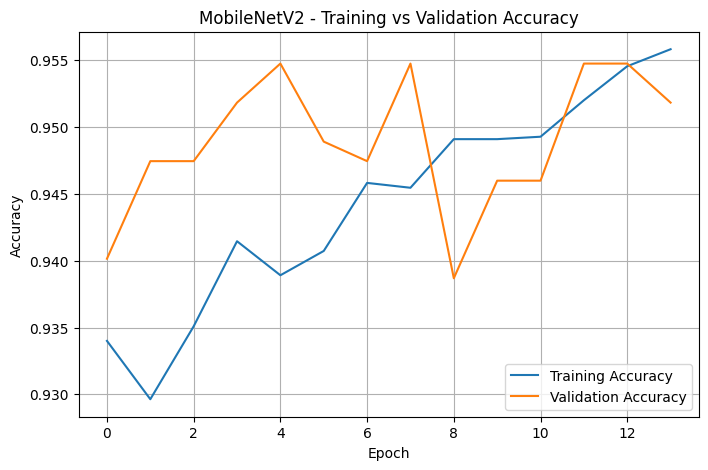

In [66]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    history_stage1_resume.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_stage1_resume.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MobileNetV2 - Training vs Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()

In [67]:
from pathlib import Path

MODEL_DIR = Path("/content/drive/MyDrive/Betel_Leaf_Models")

for file in MODEL_DIR.iterdir():
    if file.suffix.lower() == ".csv":
        print(file.name)

In [68]:
print([name for name in globals() if name.startswith("history")])

['history_stage1_resume']


In [69]:
from pathlib import Path

MODEL_DIR = Path("/content/drive/MyDrive/Betel_Leaf_Models")

for f in MODEL_DIR.iterdir():
    print(f.name)

mobilenetv2_stage1_best.keras


In [70]:
!nvidia-smi

Thu Aug 27 07:42:45 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   76C    P0             33W /   70W |    2177MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [71]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [72]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from pathlib import Path
from tensorflow import keras
from tensorflow.keras import layers

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [73]:
SPLIT_DIR = Path(
    "/content/drive/MyDrive/Betel_Leaf_DataSet_Split"
)

TRAIN_DIR = SPLIT_DIR / "train_augmented_1100"
VAL_DIR = SPLIT_DIR / "validation"
TEST_DIR = SPLIT_DIR / "test"

print("Train:", TRAIN_DIR.exists())
print("Validation:", VAL_DIR.exists())
print("Test:", TEST_DIR.exists())

Train: True
Validation: True
Test: True


In [74]:
IMG_SIZE = (224, 224)
INPUT_SHAPE = (224, 224, 3)

BATCH_SIZE = 32
NUM_CLASSES = 5
EPOCHS = 20

In [75]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

class_names = train_ds.class_names

print("\nClasses:", class_names)

Found 5500 files belonging to 5 classes.
Found 685 files belonging to 5 classes.
Found 685 files belonging to 5 classes.

Classes: ['Anthracnose', 'Healthy', 'Leaf_Curl', 'Leaf_Rot', 'Leaf_Spot']


In [76]:
for images, labels in train_ds.take(1):
    print("Image batch:", images.shape)
    print("Label batch:", labels.shape)

Image batch: (32, 224, 224, 3)
Label batch: (32, 5)


In [77]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

In [78]:
RUN_DIR = Path(
    "/content/drive/MyDrive/Betel_Leaf_Models/MobileNetV2_Final_Run"
)

RUN_DIR.mkdir(
    parents=True,
    exist_ok=True
)

BEST_MODEL_PATH = RUN_DIR / "mobilenetv2_stage1_best.keras"

LOG_PATH = RUN_DIR / "mobilenetv2_stage1_history.csv"

BACKUP_DIR = RUN_DIR / "training_backup"

print("Experiment folder:", RUN_DIR)

Experiment folder: /content/drive/MyDrive/Betel_Leaf_Models/MobileNetV2_Final_Run


In [79]:
import shutil

if RUN_DIR.exists():
    shutil.rmtree(RUN_DIR)

RUN_DIR.mkdir(
    parents=True,
    exist_ok=True
)

BEST_MODEL_PATH = RUN_DIR / "mobilenetv2_stage1_best.keras"
LOG_PATH = RUN_DIR / "mobilenetv2_stage1_history.csv"
BACKUP_DIR = RUN_DIR / "training_backup"

print("Fresh experiment folder created.")

Fresh experiment folder created.


In [80]:
tf.keras.backend.clear_session()

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=INPUT_SHAPE
)

base_model.trainable = False

print("MobileNetV2 loaded.")
print("Trainable:", base_model.trainable)

MobileNetV2 loaded.
Trainable: False


In [81]:
inputs = keras.Input(
    shape=INPUT_SHAPE
)

x = preprocess_input(inputs)

x = base_model(
    x,
    training=False
)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.3)(x)

outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)

model = keras.Model(
    inputs,
    outputs,
    name="BetelLeaf_MobileNetV2"
)

model.summary()

Model: "BetelLeaf_MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [82]:
model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [83]:
callbacks_stage1 = [

    keras.callbacks.ModelCheckpoint(
        filepath=str(BEST_MODEL_PATH),
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),

    keras.callbacks.CSVLogger(
        str(LOG_PATH),
        append=False
    ),

    keras.callbacks.BackupAndRestore(
        backup_dir=str(BACKUP_DIR)
    )
]

In [84]:
history_stage1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks_stage1
)

Epoch 1/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5853 - loss: 1.0314
Epoch 1: val_accuracy improved from None to 0.87883, saving model to /content/drive/MyDrive/Betel_Leaf_Models/MobileNetV2_Final_Run/mobilenetv2_stage1_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Betel_Leaf_Models/MobileNetV2_Final_Run/mobilenetv2_stage1_best.keras
172/172 ━━━━━━━━━━━━━━━━━━━━ 267s 1s/step - accuracy: 0.7167 - loss: 0.7389 - val_accuracy: 0.8788 - val_loss: 0.3785 - learning_rate: 0.0010
Epoch 2/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8612 - loss: 0.3947
Epoch 2: val_accuracy improved from 0.87883 to 0.91533, saving model to /content/drive/MyDrive/Betel_Leaf_Models/MobileNetV2_Final_Run/mobilenetv2_stage1_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Betel_Leaf_Models/MobileNetV2_Final_Run/mobilenetv2_stage1_best.keras
172/172 ━━━━━━━━━━━━━━━━━━━━ 249s 1s/step - accuracy: 0.8685 - loss: 0.3796 - val_accuracy: 0.9153 - val_

In [85]:
import pandas as pd

history_df = pd.read_csv(LOG_PATH)

history_df["Epoch"] = history_df["epoch"] + 1

print("Total recorded epochs:", len(history_df))

display(
    history_df[
        ["Epoch", "accuracy", "val_accuracy", "loss", "val_loss"]
    ]
)

Total recorded epochs: 20


,Epoch,accuracy,val_accuracy,loss,val_loss
0,1,0.716727,0.878832,0.738899,0.378524
1,2,0.868545,0.915328,0.379617,0.278103
2,3,0.893818,0.927007,0.309083,0.241043
3,4,0.908909,0.932847,0.260677,0.208735
4,5,0.920545,0.948905,0.230518,0.190243
5,6,0.927636,0.944526,0.211544,0.184606
6,7,0.928364,0.928467,0.200233,0.198274
7,8,0.934909,0.938686,0.184719,0.173936
8,9,0.939273,0.953285,0.176950,0.162859
9,10,0.941455,0.951825,0.169871,0.157644


In [86]:
best_acc_index = history_df["val_accuracy"].idxmax()

best_epoch = int(history_df.loc[best_acc_index, "Epoch"])
best_val_acc = history_df.loc[best_acc_index, "val_accuracy"]
best_val_loss = history_df.loc[best_acc_index, "val_loss"]

print("Best Epoch:", best_epoch)
print(f"Best Validation Accuracy: {best_val_acc * 100:.2f}%")
print(f"Validation Loss at Best Epoch: {best_val_loss:.4f}")

Best Epoch: 9
Best Validation Accuracy: 95.33%
Validation Loss at Best Epoch: 0.1629


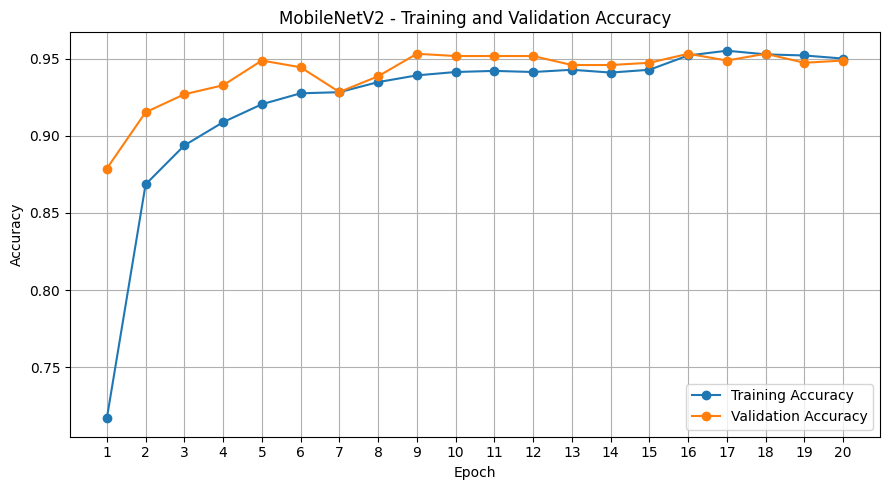

In [87]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.plot(
    history_df["Epoch"],
    history_df["accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    history_df["Epoch"],
    history_df["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MobileNetV2 - Training and Validation Accuracy")

plt.xticks(range(1, 21))
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    RUN_DIR / "mobilenetv2_stage1_accuracy_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

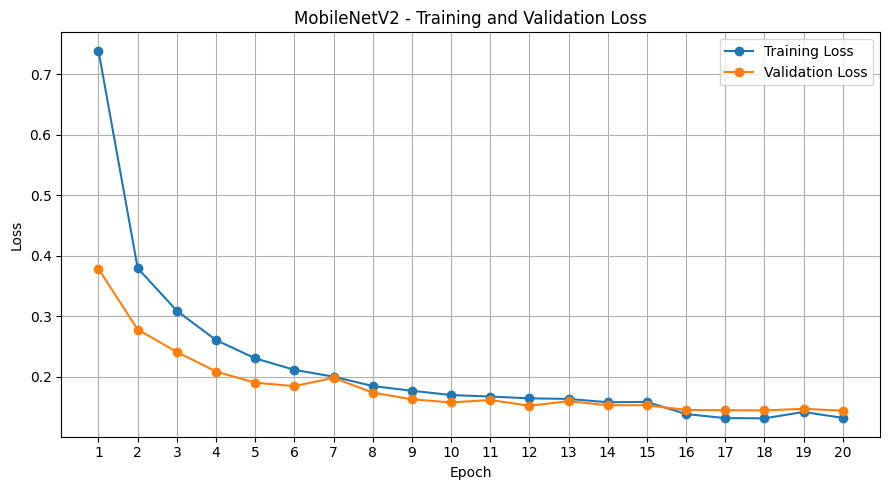

In [88]:
plt.figure(figsize=(9, 5))

plt.plot(
    history_df["Epoch"],
    history_df["loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    history_df["Epoch"],
    history_df["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MobileNetV2 - Training and Validation Loss")

plt.xticks(range(1, 21))
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    RUN_DIR / "mobilenetv2_stage1_loss_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [89]:
from tensorflow import keras

model = keras.models.load_model(BEST_MODEL_PATH)

print("Best Stage-1 MobileNetV2 loaded.")

Best Stage-1 MobileNetV2 loaded.


In [90]:
val_loss, val_accuracy = model.evaluate(
    val_ds,
    verbose=1
)

print(f"Validation Accuracy: {val_accuracy * 100:.2f}%")
print(f"Validation Loss: {val_loss:.4f}")

22/22 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.9533 - loss: 0.1629
Validation Accuracy: 95.33%
Validation Loss: 0.1629


In [91]:
for layer in model.layers:
    print(layer.name, type(layer).__name__)

input_layer_1 InputLayer
mobilenetv2_1.00_224 Functional
global_average_pooling2d GlobalAveragePooling2D
dropout Dropout
dense Dense


In [92]:
base_model = next(
    layer for layer in model.layers
    if "mobilenetv2" in layer.name.lower()
)

print("Base Model:", base_model.name)
print("Total Layers:", len(base_model.layers))

Base Model: mobilenetv2_1.00_224
Total Layers: 154


In [93]:
from tensorflow.keras import layers

base_model.trainable = True

fine_tune_at = len(base_model.layers) - 30

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

for layer in base_model.layers[fine_tune_at:]:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

print("Fine-tuning starts at layer:", fine_tune_at)

Fine-tuning starts at layer: 124


In [94]:
model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [95]:
FINE_TUNE_MODEL_PATH = (
    RUN_DIR / "mobilenetv2_finetuned_best.keras"
)

FINE_TUNE_LOG_PATH = (
    RUN_DIR / "mobilenetv2_finetuning_history.csv"
)

FINE_TUNE_BACKUP_DIR = (
    RUN_DIR / "finetuning_backup"
)

In [96]:
callbacks_finetune = [

    keras.callbacks.ModelCheckpoint(
        filepath=str(FINE_TUNE_MODEL_PATH),
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),

    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),

    keras.callbacks.CSVLogger(
        str(FINE_TUNE_LOG_PATH),
        append=False
    ),

    keras.callbacks.BackupAndRestore(
        backup_dir=str(FINE_TUNE_BACKUP_DIR)
    )
]

In [97]:
history_finetune = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks_finetune
)

Epoch 1/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9440 - loss: 0.1640
Epoch 1: val_accuracy improved from None to 0.95328, saving model to /content/drive/MyDrive/Betel_Leaf_Models/MobileNetV2_Final_Run/mobilenetv2_finetuned_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Betel_Leaf_Models/MobileNetV2_Final_Run/mobilenetv2_finetuned_best.keras
172/172 ━━━━━━━━━━━━━━━━━━━━ 264s 1s/step - accuracy: 0.9467 - loss: 0.1551 - val_accuracy: 0.9533 - val_loss: 0.1415 - learning_rate: 1.0000e-05
Epoch 2/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9597 - loss: 0.1150
Epoch 2: val_accuracy improved from 0.95328 to 0.96496, saving model to /content/drive/MyDrive/Betel_Leaf_Models/MobileNetV2_Final_Run/mobilenetv2_finetuned_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Betel_Leaf_Models/MobileNetV2_Final_Run/mobilenetv2_finetuned_best.keras
172/172 ━━━━━━━━━━━━━━━━━━━━ 254s 1s/step - accuracy: 0.9600 - loss: 0.1129 - val_accurac

In [98]:
from tensorflow import keras

best_finetuned_model = keras.models.load_model(
    FINE_TUNE_MODEL_PATH
)

print("Best fine-tuned model loaded.")

Best fine-tuned model loaded.


In [99]:
ft_val_loss, ft_val_accuracy = best_finetuned_model.evaluate(
    val_ds,
    verbose=1
)

print(f"Fine-tuned Validation Accuracy: {ft_val_accuracy * 100:.2f}%")
print(f"Fine-tuned Validation Loss: {ft_val_loss:.4f}")

22/22 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.9752 - loss: 0.1141
Fine-tuned Validation Accuracy: 97.52%
Fine-tuned Validation Loss: 0.1141


In [100]:
best_stage1_model = keras.models.load_model(
    BEST_MODEL_PATH
)

s1_val_loss, s1_val_accuracy = best_stage1_model.evaluate(
    val_ds,
    verbose=1
)

print(f"Stage-1 Validation Accuracy: {s1_val_accuracy * 100:.2f}%")
print(f"Stage-1 Validation Loss: {s1_val_loss:.4f}")

22/22 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/step - accuracy: 0.9533 - loss: 0.1629
Stage-1 Validation Accuracy: 95.33%
Stage-1 Validation Loss: 0.1629


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import tensorflow as tf
import numpy as np
from pathlib import Path
from tensorflow import keras

In [3]:
SPLIT_DIR = Path("/content/drive/MyDrive/Betel_Leaf_DataSet_Split")

TEST_DIR = SPLIT_DIR / "test"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

In [4]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

class_names = test_ds.class_names

test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

print(class_names)

Found 685 files belonging to 5 classes.
['Anthracnose', 'Healthy', 'Leaf_Curl', 'Leaf_Rot', 'Leaf_Spot']


In [5]:
RUN_DIR = Path(
    "/content/drive/MyDrive/Betel_Leaf_Models/MobileNetV2_Final_Run"
)

FINE_TUNE_MODEL_PATH = (
    RUN_DIR / "mobilenetv2_finetuned_best.keras"
)

final_model = keras.models.load_model(
    FINE_TUNE_MODEL_PATH
)

print("Fine-tuned MobileNetV2 loaded successfully.")

Fine-tuned MobileNetV2 loaded successfully.


In [7]:
test_loss, test_accuracy = final_model.evaluate(
    test_ds,
    verbose=1
)

print(f"Final Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Final Test Loss: {test_loss:.4f}")

22/22 ━━━━━━━━━━━━━━━━━━━━ 318s 14s/step - accuracy: 0.9577 - loss: 0.1264
Final Test Accuracy: 95.77%
Final Test Loss: 0.1264


In [8]:
import numpy as np

y_prob = final_model.predict(
    test_ds,
    verbose=1
)

y_pred = np.argmax(y_prob, axis=1)

y_true_onehot = np.concatenate(
    [labels.numpy() for images, labels in test_ds],
    axis=0
)

y_true = np.argmax(
    y_true_onehot,
    axis=1
)

print("Total Test Images:", len(y_true))

22/22 ━━━━━━━━━━━━━━━━━━━━ 320s 14s/step
Total Test Images: 685


In [9]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

precision = precision_score(
    y_true,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_true,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_true,
    y_pred,
    average="weighted"
)

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

Precision: 0.9583
Recall:    0.9577
F1-score:  0.9576


In [10]:
from sklearn.metrics import classification_report

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
)

print(report)

              precision    recall  f1-score   support

 Anthracnose     0.9846    0.9343    0.9588       137
     Healthy     0.9577    0.9927    0.9749       137
   Leaf_Curl     1.0000    1.0000    1.0000       137
    Leaf_Rot     0.9103    0.9635    0.9362       137
   Leaf_Spot     0.9389    0.8978    0.9179       137

    accuracy                         0.9577       685
   macro avg     0.9583    0.9577    0.9576       685
weighted avg     0.9583    0.9577    0.9576       685



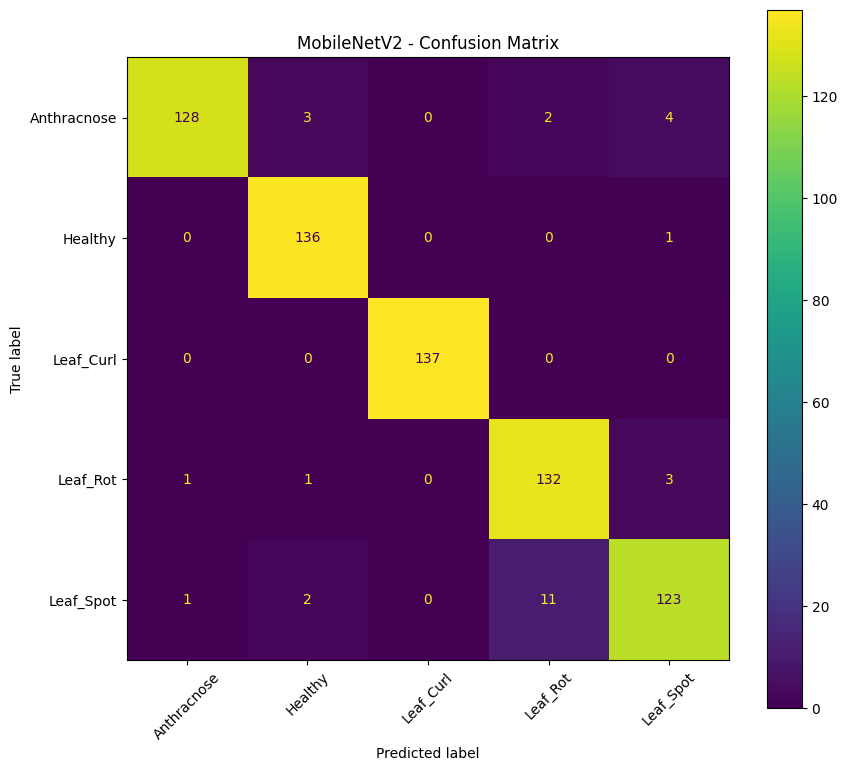

In [11]:
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay
)

cm = confusion_matrix(
    y_true,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(9, 8))

disp.plot(
    ax=ax,
    xticks_rotation=45,
    values_format="d"
)

plt.title(
    "MobileNetV2 - Confusion Matrix"
)

plt.tight_layout()

plt.savefig(
    RUN_DIR / "mobilenetv2_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [12]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(
    y_true_onehot,
    y_prob,
    multi_class="ovr",
    average="macro"
)

print(f"ROC-AUC: {roc_auc:.4f}")

ROC-AUC: 0.9974


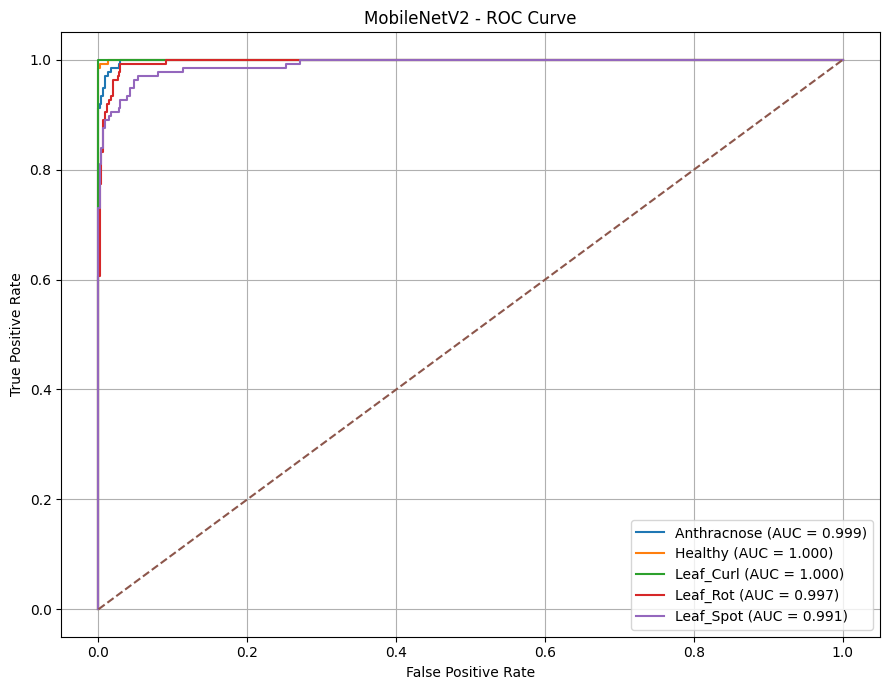

In [13]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(9, 7))

for i, class_name in enumerate(class_names):

    fpr, tpr, _ = roc_curve(
        y_true_onehot[:, i],
        y_prob[:, i]
    )

    class_auc = auc(
        fpr,
        tpr
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{class_name} (AUC = {class_auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("MobileNetV2 - ROC Curve")

plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    RUN_DIR / "mobilenetv2_roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [14]:
print("\n===== FINAL MOBILENETV2 RESULTS =====")

print(f"Test Accuracy : {test_accuracy * 100:.2f}%")
print(f"Test Loss     : {test_loss:.4f}")
print(f"Precision     : {precision:.4f}")
print(f"Recall        : {recall:.4f}")
print(f"F1-score      : {f1:.4f}")
print(f"ROC-AUC       : {roc_auc:.4f}")


===== FINAL MOBILENETV2 RESULTS =====
Test Accuracy : 95.77%
Test Loss     : 0.1264
Precision     : 0.9583
Recall        : 0.9577
F1-score      : 0.9576
ROC-AUC       : 0.9974


In [15]:
from sklearn.metrics import classification_report
import pandas as pd

report_dict = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4,
    output_dict=True
)

report_df = pd.DataFrame(report_dict).transpose()

display(report_df)

report_df.to_csv(
    RUN_DIR / "mobilenetv2_classification_report.csv"
)

,precision,recall,f1-score,support
Anthracnose,0.984615,0.934307,0.958801,137.000000
Healthy,0.957746,0.992701,0.974910,137.000000
Leaf_Curl,1.000000,1.000000,1.000000,137.000000
Leaf_Rot,0.910345,0.963504,0.936170,137.000000
Leaf_Spot,0.938931,0.897810,0.917910,137.000000
accuracy,0.957664,0.957664,0.957664,0.957664
macro avg,0.958328,0.957664,0.957559,685.000000
weighted avg,0.958328,0.957664,0.957559,685.000000


In [16]:
final_results = pd.DataFrame([{
    "Model": "MobileNetV2",
    "Test Accuracy": test_accuracy,
    "Test Loss": test_loss,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1,
    "ROC AUC": roc_auc
}])

final_results.to_csv(
    RUN_DIR / "mobilenetv2_final_results.csv",
    index=False
)

display(final_results)

,Model,Test Accuracy,Test Loss,Precision,Recall,F1 Score,ROC AUC
0,MobileNetV2,0.957664,0.126418,0.958328,0.957664,0.957559,0.997373


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

RUN_DIR = Path(
    "/content/drive/MyDrive/Betel_Leaf_Models/MobileNetV2_Final_Run"
)

STAGE1_LOG = RUN_DIR / "mobilenetv2_stage1_history.csv"
FINETUNE_LOG = RUN_DIR / "mobilenetv2_finetuning_history.csv"

stage1_df = pd.read_csv(STAGE1_LOG)
finetune_df = pd.read_csv(FINETUNE_LOG)

stage1_df["Epoch"] = stage1_df["epoch"] + 1
finetune_df["Epoch"] = finetune_df["epoch"] + 1

print("Stage-1 epochs:", len(stage1_df))
print("Fine-tuning epochs:", len(finetune_df))

Stage-1 epochs: 20
Fine-tuning epochs: 10


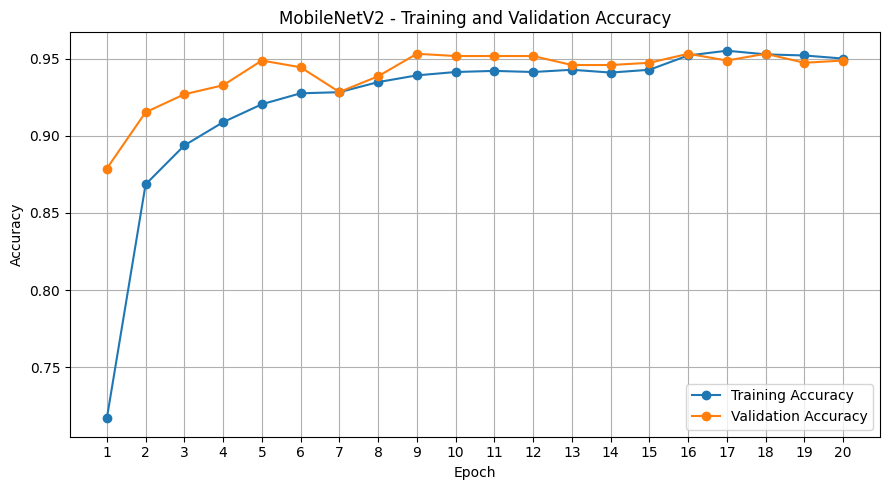

In [18]:
plt.figure(figsize=(9, 5))

plt.plot(
    stage1_df["Epoch"],
    stage1_df["accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    stage1_df["Epoch"],
    stage1_df["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MobileNetV2 - Training and Validation Accuracy")

plt.xticks(range(1, 21))
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    RUN_DIR / "mobilenetv2_stage1_accuracy_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

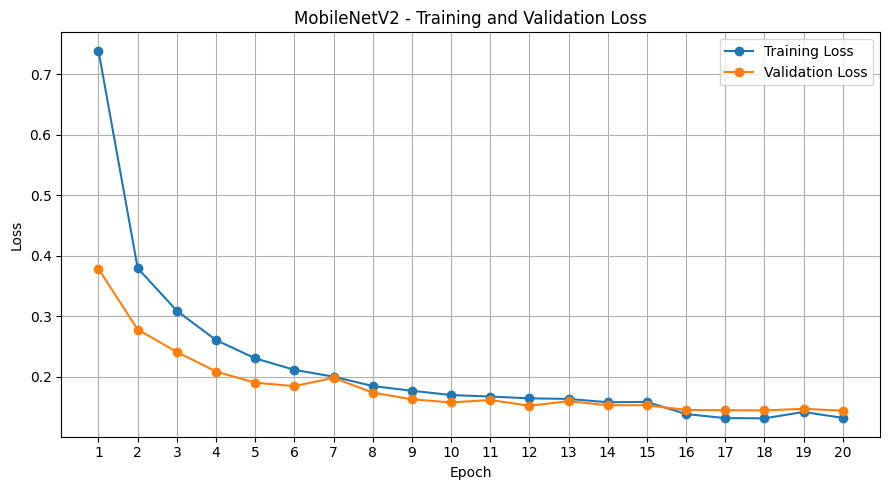

In [19]:
plt.figure(figsize=(9, 5))

plt.plot(
    stage1_df["Epoch"],
    stage1_df["loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    stage1_df["Epoch"],
    stage1_df["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MobileNetV2 - Training and Validation Loss")

plt.xticks(range(1, 21))
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    RUN_DIR / "mobilenetv2_stage1_loss_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

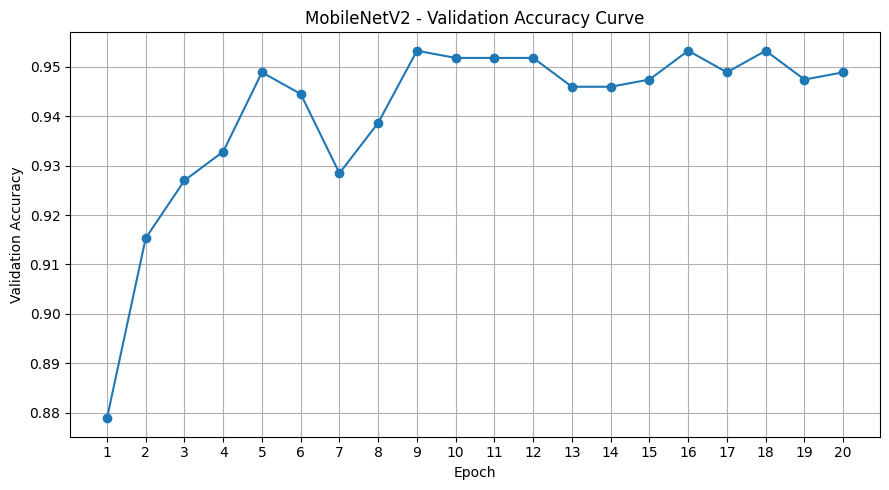

In [20]:
plt.figure(figsize=(9, 5))

plt.plot(
    stage1_df["Epoch"],
    stage1_df["val_accuracy"],
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("MobileNetV2 - Validation Accuracy Curve")

plt.xticks(range(1, 21))
plt.grid(True)

plt.tight_layout()

plt.savefig(
    RUN_DIR / "mobilenetv2_validation_accuracy_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

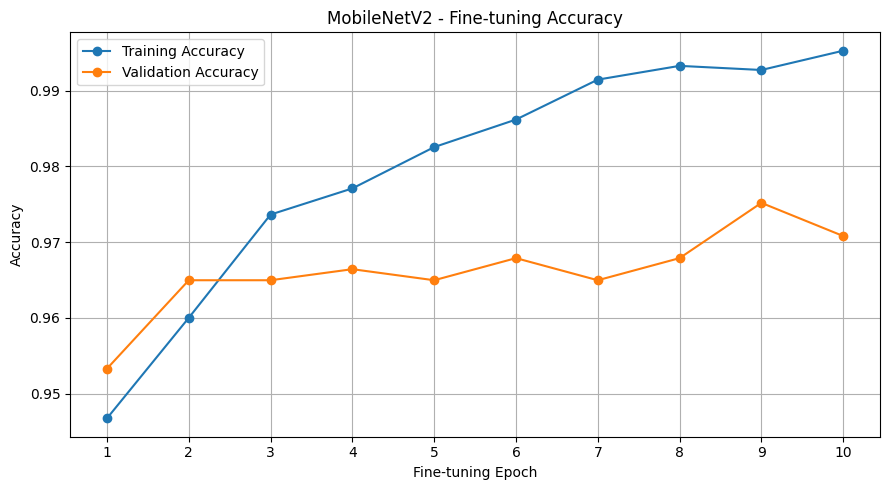

In [21]:
plt.figure(figsize=(9, 5))

plt.plot(
    finetune_df["Epoch"],
    finetune_df["accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    finetune_df["Epoch"],
    finetune_df["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Fine-tuning Epoch")
plt.ylabel("Accuracy")
plt.title("MobileNetV2 - Fine-tuning Accuracy")

plt.xticks(range(1, len(finetune_df) + 1))
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    RUN_DIR / "mobilenetv2_finetuning_accuracy_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

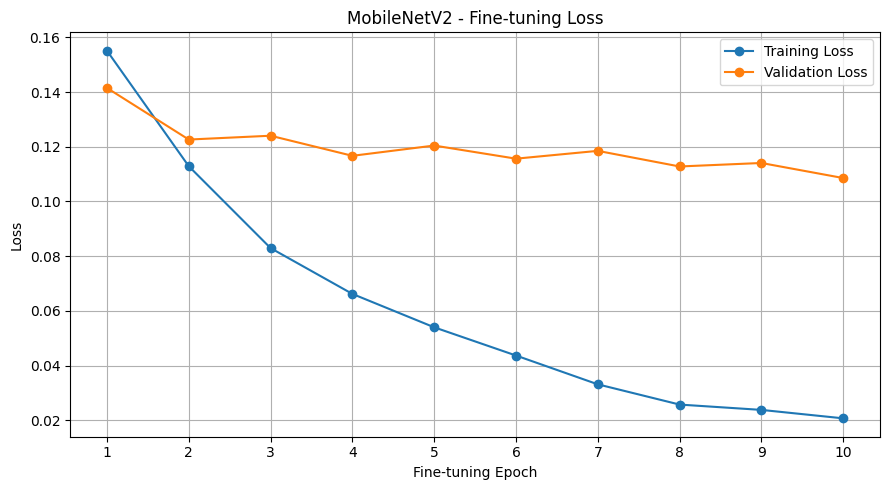

In [22]:
plt.figure(figsize=(9, 5))

plt.plot(
    finetune_df["Epoch"],
    finetune_df["loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    finetune_df["Epoch"],
    finetune_df["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Fine-tuning Epoch")
plt.ylabel("Loss")
plt.title("MobileNetV2 - Fine-tuning Loss")

plt.xticks(range(1, len(finetune_df) + 1))
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    RUN_DIR / "mobilenetv2_finetuning_loss_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

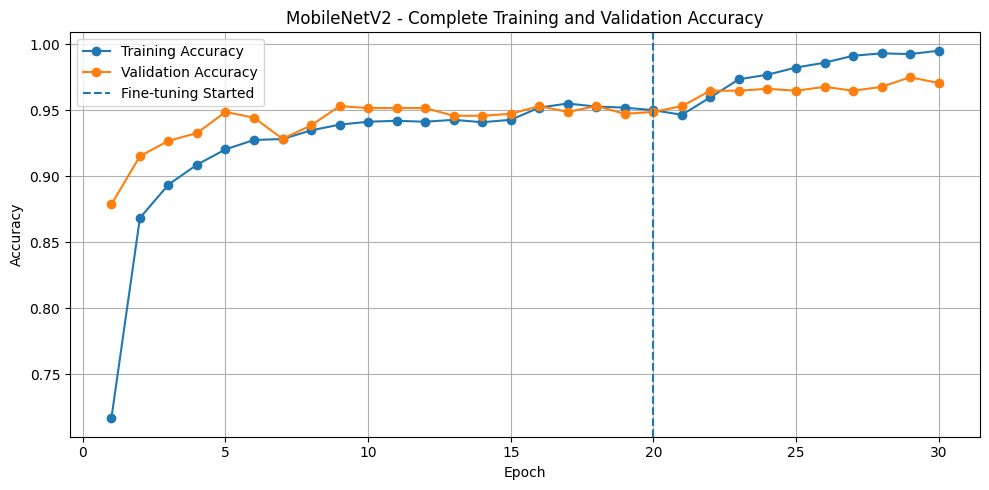

In [23]:
combined_train_acc = list(stage1_df["accuracy"]) + list(
    finetune_df["accuracy"]
)

combined_val_acc = list(stage1_df["val_accuracy"]) + list(
    finetune_df["val_accuracy"]
)

combined_epochs = range(
    1,
    len(combined_train_acc) + 1
)

plt.figure(figsize=(10, 5))

plt.plot(
    combined_epochs,
    combined_train_acc,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    combined_epochs,
    combined_val_acc,
    marker="o",
    label="Validation Accuracy"
)

plt.axvline(
    x=20,
    linestyle="--",
    label="Fine-tuning Started"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "MobileNetV2 - Complete Training and Validation Accuracy"
)

plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    RUN_DIR / "mobilenetv2_complete_accuracy_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

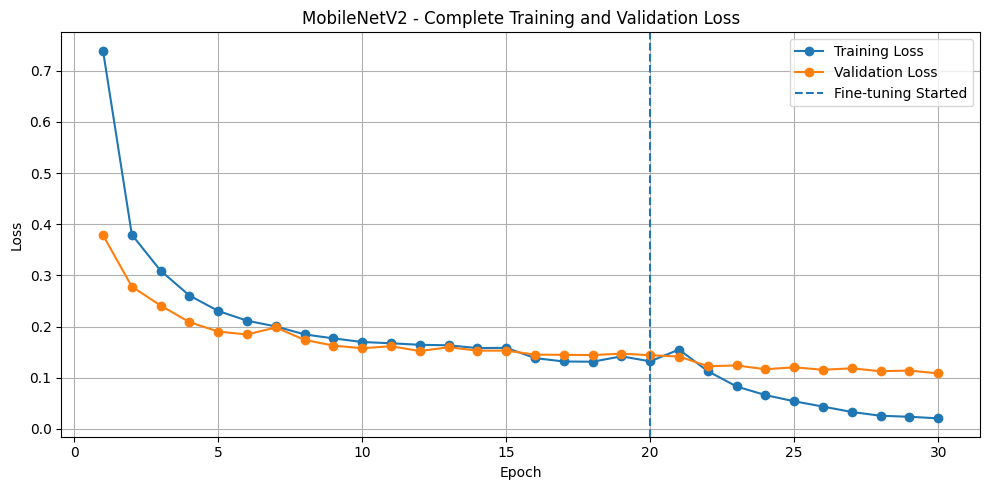

In [24]:
combined_train_loss = list(stage1_df["loss"]) + list(
    finetune_df["loss"]
)

combined_val_loss = list(stage1_df["val_loss"]) + list(
    finetune_df["val_loss"]
)

combined_epochs = range(
    1,
    len(combined_train_loss) + 1
)

plt.figure(figsize=(10, 5))

plt.plot(
    combined_epochs,
    combined_train_loss,
    marker="o",
    label="Training Loss"
)

plt.plot(
    combined_epochs,
    combined_val_loss,
    marker="o",
    label="Validation Loss"
)

plt.axvline(
    x=20,
    linestyle="--",
    label="Fine-tuning Started"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "MobileNetV2 - Complete Training and Validation Loss"
)

plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    RUN_DIR / "mobilenetv2_complete_loss_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# =========================
# PATHS
# =========================

RUN_DIR = Path(
    "/content/drive/MyDrive/Betel_Leaf_Models/MobileNetV2_Final_Run"
)

CURVE_DIR = RUN_DIR / "Curves"
CURVE_DIR.mkdir(parents=True, exist_ok=True)

STAGE1_LOG = RUN_DIR / "mobilenetv2_stage1_history.csv"
FINETUNE_LOG = RUN_DIR / "mobilenetv2_finetuning_history.csv"

# =========================
# LOAD LOG FILES
# =========================

stage1_df = pd.read_csv(STAGE1_LOG)
finetune_df = pd.read_csv(FINETUNE_LOG)

stage1_df["Epoch"] = stage1_df["epoch"] + 1
finetune_df["Epoch"] = finetune_df["epoch"] + 1

print("Stage-1 Epochs:", len(stage1_df))
print("Fine-tuning Epochs:", len(finetune_df))

# =========================
# 1. STAGE-1 ACCURACY CURVE
# =========================

plt.figure(figsize=(10, 6))

plt.plot(
    stage1_df["Epoch"],
    stage1_df["accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    stage1_df["Epoch"],
    stage1_df["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MobileNetV2 - Stage-1 Training and Validation Accuracy")
plt.xticks(range(1, len(stage1_df) + 1))
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    CURVE_DIR / "01_stage1_accuracy_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

# =========================
# 2. STAGE-1 LOSS CURVE
# =========================

plt.figure(figsize=(10, 6))

plt.plot(
    stage1_df["Epoch"],
    stage1_df["loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    stage1_df["Epoch"],
    stage1_df["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MobileNetV2 - Stage-1 Training and Validation Loss")
plt.xticks(range(1, len(stage1_df) + 1))
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    CURVE_DIR / "02_stage1_loss_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

# =========================
# 3. VALIDATION ACCURACY CURVE
# =========================

plt.figure(figsize=(10, 6))

plt.plot(
    stage1_df["Epoch"],
    stage1_df["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("MobileNetV2 - Validation Accuracy Curve")
plt.xticks(range(1, len(stage1_df) + 1))
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    CURVE_DIR / "03_validation_accuracy_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

# =========================
# 4. FINE-TUNING ACCURACY CURVE
# =========================

plt.figure(figsize=(10, 6))

plt.plot(
    finetune_df["Epoch"],
    finetune_df["accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    finetune_df["Epoch"],
    finetune_df["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Fine-tuning Epoch")
plt.ylabel("Accuracy")
plt.title("MobileNetV2 - Fine-tuning Accuracy")
plt.xticks(range(1, len(finetune_df) + 1))
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    CURVE_DIR / "04_finetuning_accuracy_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

# =========================
# 5. FINE-TUNING LOSS CURVE
# =========================

plt.figure(figsize=(10, 6))

plt.plot(
    finetune_df["Epoch"],
    finetune_df["loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    finetune_df["Epoch"],
    finetune_df["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Fine-tuning Epoch")
plt.ylabel("Loss")
plt.title("MobileNetV2 - Fine-tuning Loss")
plt.xticks(range(1, len(finetune_df) + 1))
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    CURVE_DIR / "05_finetuning_loss_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

# =========================
# 6. COMBINED ACCURACY CURVE
# =========================

combined_train_acc = (
    list(stage1_df["accuracy"]) +
    list(finetune_df["accuracy"])
)

combined_val_acc = (
    list(stage1_df["val_accuracy"]) +
    list(finetune_df["val_accuracy"])
)

combined_epochs = range(
    1,
    len(combined_train_acc) + 1
)

plt.figure(figsize=(11, 6))

plt.plot(
    combined_epochs,
    combined_train_acc,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    combined_epochs,
    combined_val_acc,
    marker="o",
    label="Validation Accuracy"
)

plt.axvline(
    x=len(stage1_df),
    linestyle="--",
    label="Fine-tuning Started"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MobileNetV2 - Complete Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    CURVE_DIR / "06_combined_accuracy_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

# =========================
# 7. COMBINED LOSS CURVE
# =========================

combined_train_loss = (
    list(stage1_df["loss"]) +
    list(finetune_df["loss"])
)

combined_val_loss = (
    list(stage1_df["val_loss"]) +
    list(finetune_df["val_loss"])
)

combined_epochs = range(
    1,
    len(combined_train_loss) + 1
)

plt.figure(figsize=(11, 6))

plt.plot(
    combined_epochs,
    combined_train_loss,
    marker="o",
    label="Training Loss"
)

plt.plot(
    combined_epochs,
    combined_val_loss,
    marker="o",
    label="Validation Loss"
)

plt.axvline(
    x=len(stage1_df),
    linestyle="--",
    label="Fine-tuning Started"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MobileNetV2 - Complete Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    CURVE_DIR / "07_combined_loss_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print("\nAll curves saved successfully.")
print("Saved location:")
print(CURVE_DIR)

Stage-1 Epochs: 20
Fine-tuning Epochs: 10

All curves saved successfully.
Saved location:
/content/drive/MyDrive/Betel_Leaf_Models/MobileNetV2_Final_Run/Curves


In [26]:
val_loss, val_accuracy = final_model.evaluate(
    val_ds,
    verbose=1
)

print(f"Validation Accuracy: {val_accuracy * 100:.2f}%")

NameError: name 'val_ds' is not defined

In [27]:
import tensorflow as tf
from pathlib import Path

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

SPLIT_DIR = Path("/content/drive/MyDrive/Betel_Leaf_DataSet_Split")
VAL_DIR = SPLIT_DIR / "validation"

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

val_ds = val_ds.prefetch(tf.data.AUTOTUNE)

print("Validation dataset loaded.")

Found 685 files belonging to 5 classes.
Validation dataset loaded.


In [28]:
val_loss, val_accuracy = final_model.evaluate(
    val_ds,
    verbose=1
)

print(f"Validation Accuracy: {val_accuracy * 100:.2f}%")

22/22 ━━━━━━━━━━━━━━━━━━━━ 365s 15s/step - accuracy: 0.9752 - loss: 0.1141
Validation Accuracy: 97.52%


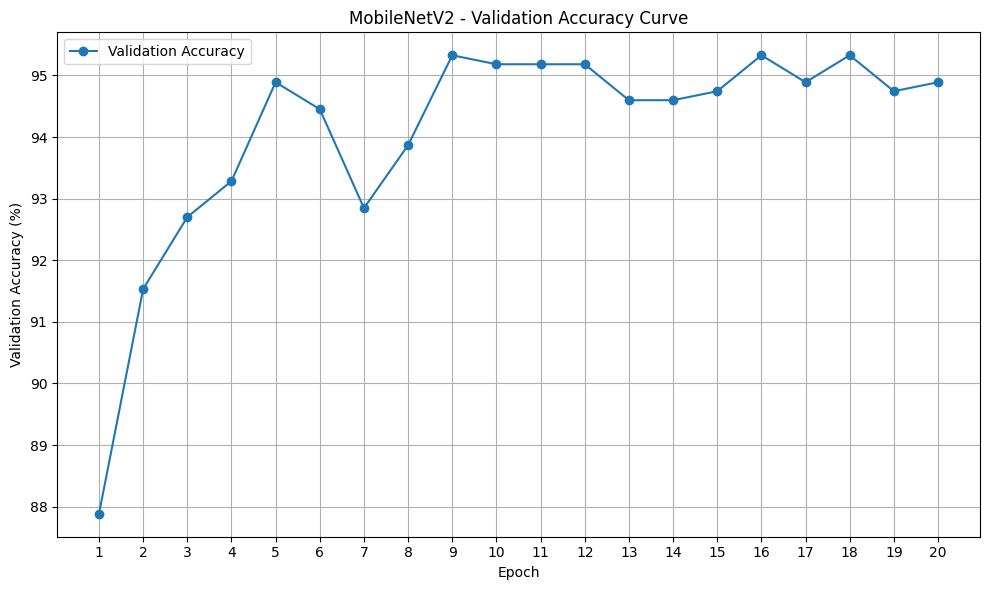

Validation Accuracy Curve saved successfully.


In [30]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

RUN_DIR = Path(
    "/content/drive/MyDrive/Betel_Leaf_Models/MobileNetV2_Final_Run"
)

LOG_PATH = RUN_DIR / "mobilenetv2_stage1_history.csv"

# Load CSV
history_df = pd.read_csv(LOG_PATH)

# Epoch 0-19 → 1-20
history_df["Epoch"] = history_df["epoch"] + 1

# Validation accuracy to percentage
history_df["val_accuracy_percent"] = (
    history_df["val_accuracy"] * 100
)

# Plot
plt.figure(figsize=(10, 6))

plt.plot(
    history_df["Epoch"],
    history_df["val_accuracy_percent"],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("MobileNetV2 - Validation Accuracy Curve")

plt.xticks(range(1, 21))
plt.legend()
plt.grid(True)

plt.tight_layout()

# Save to Drive
plt.savefig(
    RUN_DIR / "mobilenetv2_validation_accuracy_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Validation Accuracy Curve saved successfully.")

In [31]:
print(
    history_df[
        ["Epoch", "val_accuracy_percent"]
    ]
)

    Epoch  val_accuracy_percent
0       1             87.883210
1       2             91.532844
2       3             92.700732
3       4             93.284672
4       5             94.890511
5       6             94.452554
6       7             92.846715
7       8             93.868613
8       9             95.328468
9      10             95.182484
10     11             95.182484
11     12             95.182484
12     13             94.598538
13     14             94.598538
14     15             94.744527
15     16             95.328468
16     17             94.890511
17     18             95.328468
18     19             94.744527
19     20             94.890511
